# Decision Tree Classifier using Gini Index

This notebook applies a Decision Tree (CART) using **Gini Index** to predict lawn tractor ownership.

## 1. Import Libraries

In [1]:

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt


## 2. Create Dataset

In [2]:

data = {
    "Income": [60,75,85.5,52.8,64.8,64.8,61.5,43.2,87,84,110.1,49.2,108,59.2,82.8,66,69,47.4,93,33,51,51,81,63],
    "LotSize": [18.4,19.6,16.8,20.8,21.6,17.2,20.8,20.4,23.6,17.6,19.2,17.6,17.6,16,22.4,18.4,20,16.4,20.8,18.8,22,14,20,14.8],
    "Owner": [
        "Owner","Nonowner","Owner","Nonowner","Owner","Nonowner","Owner","Nonowner",
        "Owner","Nonowner","Owner","Nonowner","Owner","Nonowner","Owner","Nonowner",
        "Owner","Nonowner","Owner","Nonowner","Owner","Nonowner","Owner","Nonowner"
    ]
}

df = pd.DataFrame(data)
df


,Income,LotSize,Owner
0,60.0,18.4,Owner
1,75.0,19.6,Nonowner
2,85.5,16.8,Owner
3,52.8,20.8,Nonowner
4,64.8,21.6,Owner
5,64.8,17.2,Nonowner
6,61.5,20.8,Owner
7,43.2,20.4,Nonowner
8,87.0,23.6,Owner
9,84.0,17.6,Nonowner


## 3. Encode Target Variable

In [3]:

df["Owner"] = df["Owner"].map({"Owner": 1, "Nonowner": 0})
X = df[["Income", "LotSize"]]
y = df["Owner"]


## 4. Train Decision Tree (Gini Index)

In [4]:

model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
model.fit(X, y)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 5. Visualize the Decision Tree

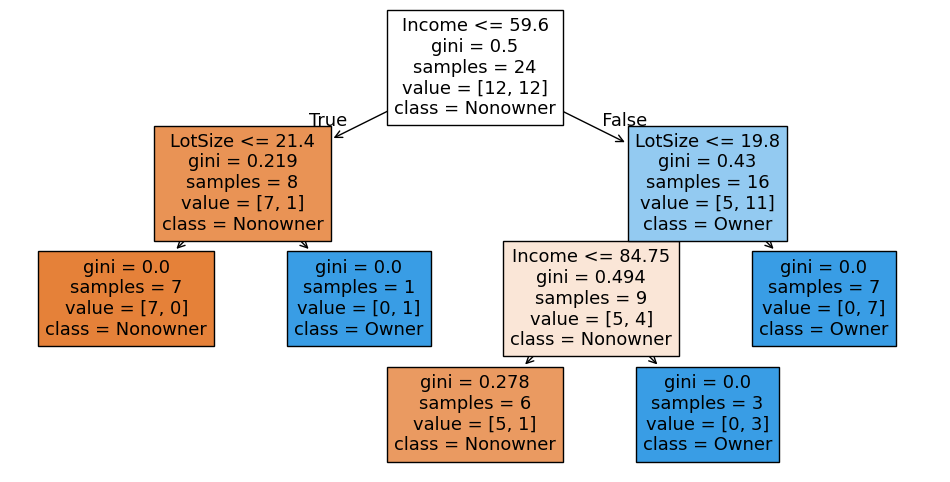

In [5]:

plt.figure(figsize=(12,6))
tree.plot_tree(
    model,
    feature_names=["Income", "LotSize"],
    class_names=["Nonowner", "Owner"],
    filled=True
)
plt.show()


## 6. Decision Rules

In [6]:

from sklearn.tree import export_text
rules = export_text(model, feature_names=["Income", "LotSize"])
print(rules)


|--- Income <= 59.60
|   |--- LotSize <= 21.40
|   |   |--- class: 0
|   |--- LotSize >  21.40
|   |   |--- class: 1
|--- Income >  59.60
|   |--- LotSize <= 19.80
|   |   |--- Income <= 84.75
|   |   |   |--- class: 0
|   |   |--- Income >  84.75
|   |   |   |--- class: 1
|   |--- LotSize >  19.80
|   |   |--- class: 1

